# "I noticed 19% of rows had extreme DebtRatio values, and traced it back to missing income data — when income is unknown, DebtRatio becomes mathematically unstable, since it's a division by an unreliable denominator."

In [8]:
import pandas as pd

df = pd.read_csv(r'C:\Users\uttam prajapat\Documents\Resume\3rd project\cs-training.csv')
print("Data shape :",df.shape)
print("Null values in each column:\n", df.isnull().sum())

Data shape : (150000, 12)
Null values in each column:
 Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [9]:
df = df.drop(['Unnamed: 0'],axis = 1)
print("shape : ",df.shape)
df['SeriousDlqin2yrs'].value_counts(normalize = True)

shape :  (150000, 11)


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [10]:
# Handle the two missing-value columns
# MonthlyIncome: ~20% missing — too much to drop rows, use median (robust to outliers, income is often skewed)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# NumberOfDependents: ~2.6% missing — small enough, but still better to impute than drop
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("Total null values:", df.isnull().sum().sum())

Total null values: 0


In [11]:
# Look for garbage/impossible values — this dataset is known to have some
print("Age range:", df['age'].min(), "to", df['age'].max())
print("Age = 0 count:", (df['age'] == 0).sum())
print()
df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 
          'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 
          'NumberOfTime60-89DaysPastDueNotWorse']].describe()

Age range: 0 to 109
Age = 0 count: 1



,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,6.048438,353.005076,0.421033,0.265973,0.240387
std,249.755371,2037.818523,4.192781,4.169304,4.155179
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,0.175074,0.000000,0.000000,0.000000
50%,0.154181,0.366508,0.000000,0.000000,0.000000
75%,0.559046,0.868254,0.000000,0.000000,0.000000
max,50708.000000,329664.000000,98.000000,98.000000,98.000000


# DebtRatio > 10: 28,877 rows — that's 19.25% of our entire dataset

MonthlyIncome had ~20% missing — suspiciously close to this 19.25%

In [12]:
# Check how many rows are affected by each issue

print("Age = 0 rows:", (df['age'] == 0).sum())
print()
print("RevolvingUtilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print("DebtRatio > 10:", (df['DebtRatio'] > 10).sum())
print()
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    print(f"{col} == 96 or 98:", df[col].isin([96, 98]).sum())

Age = 0 rows: 1

RevolvingUtilization > 2: 371
DebtRatio > 10: 28877

NumberOfTime30-59DaysPastDueNotWorse == 96 or 98: 269
NumberOfTimes90DaysLate == 96 or 98: 269
NumberOfTime60-89DaysPastDueNotWorse == 96 or 98: 269


In [13]:
# Cell: Check if extreme DebtRatio rows overlap with rows that HAD missing MonthlyIncome
# (we already filled those with median, so we need to re-check against the original nulls)
# First, let's just check: do extreme DebtRatio rows have suspiciously low/zero MonthlyIncome now?
extreme_debt = df[df['DebtRatio'] > 10]
print("Median MonthlyIncome for extreme DebtRatio rows:", extreme_debt['MonthlyIncome'].median())
print("Median MonthlyIncome for normal rows:", df[df['DebtRatio'] <= 10]['MonthlyIncome'].median())
print()
print("How many extreme DebtRatio rows have MonthlyIncome == the median we filled in:", 
      (extreme_debt['MonthlyIncome'] == df['MonthlyIncome'].median()).sum())

Median MonthlyIncome for extreme DebtRatio rows: 5400.0
Median MonthlyIncome for normal rows: 5400.0

How many extreme DebtRatio rows have MonthlyIncome == the median we filled in: 26771


In [14]:
# Cell: Cap DebtRatio at a reasonable ceiling instead of dropping 19% of rows
# Most real DebtRatios sit under ~5; we'll cap at 10 to be generous but stop the absurd values
df['DebtRatio'] = df['DebtRatio'].clip(upper=10)
print("New DebtRatio max:", df['DebtRatio'].max())
print("Rows still above 10:", (df['DebtRatio'] > 10).sum())

New DebtRatio max: 10.0
Rows still above 10: 0


In [15]:
# Cell: Same capping approach for RevolvingUtilization (only 371 rows, but same logic — a ratio shouldn't be in the thousands)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
print("New max:", df['RevolvingUtilizationOfUnsecuredLines'].max())

New max: 2.0


In [16]:
# Cell: Now handle the 96/98 sentinel codes and the age=0 row
# Replace 96/98 with NaN, then fill with 0 (most people have 0 late payments, and 269 rows is small enough this is safe)
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    df[col] = df[col].replace([96, 98], 0)

df = df[df['age'] > 0]  # drop the 1 impossible row
print("Final shape:", df.shape)

Final shape: (149999, 11)


In [17]:
# Cell: Calculate VIF for all numeric features
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop('SeriousDlqin2yrs', axis='columns')

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,Feature,VIF
5,NumberOfOpenCreditLinesAndLoans,4.578405
1,age,4.515160
7,NumberRealEstateLoansOrLines,2.280504
0,RevolvingUtilizationOfUnsecuredLines,1.794953
9,NumberOfDependents,1.471947
3,DebtRatio,1.388717
2,NumberOfTime30-59DaysPastDueNotWorse,1.325543
4,MonthlyIncome,1.271405
8,NumberOfTime60-89DaysPastDueNotWorse,1.230382
6,NumberOfTimes90DaysLate,1.201662


In [18]:
# Cell: Engineer a composite delinquency feature — a real, common credit-risk practice
df['TotalPastDueEvents'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] + 
    df['NumberOfTime60-89DaysPastDueNotWorse'] + 
    df['NumberOfTimes90DaysLate']
)
print(df['TotalPastDueEvents'].describe())

count    149999.000000
mean          0.400349
std           1.101292
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          19.000000
Name: TotalPastDueEvents, dtype: float64


In [19]:
# Cell: Re-check VIF now that the composite feature is included alongside its components
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop('SeriousDlqin2yrs', axis='columns')

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

c:\Users\uttam prajapat\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
2,NumberOfTime30-59DaysPastDueNotWorse,inf
8,NumberOfTime60-89DaysPastDueNotWorse,inf
6,NumberOfTimes90DaysLate,inf
10,TotalPastDueEvents,inf
5,NumberOfOpenCreditLinesAndLoans,4.578405
1,age,4.515160
7,NumberRealEstateLoansOrLines,2.280504
0,RevolvingUtilizationOfUnsecuredLines,1.794953
9,NumberOfDependents,1.471947
3,DebtRatio,1.388717


In [20]:
# Cell: Drop the 3 original granular columns, keep the single composite — this is the actual "elimination" step
df_final = df.drop(['NumberOfTime30-59DaysPastDueNotWorse', 
                     'NumberOfTime60-89DaysPastDueNotWorse', 
                     'NumberOfTimes90DaysLate'], axis='columns')

# Confirm VIF is now clean
X_final = df_final.drop('SeriousDlqin2yrs', axis='columns')
vif_final = pd.DataFrame()
vif_final['Feature'] = X_final.columns
vif_final['VIF'] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
vif_final.sort_values('VIF', ascending=False)

,Feature,VIF
4,NumberOfOpenCreditLinesAndLoans,4.527688
1,age,4.507937
5,NumberRealEstateLoansOrLines,2.278794
0,RevolvingUtilizationOfUnsecuredLines,1.791868
6,NumberOfDependents,1.471947
2,DebtRatio,1.388457
3,MonthlyIncome,1.271402
7,TotalPastDueEvents,1.268211


# you took three separate "how many times were they late" columns, combined them into one clean "total late payments" number, confirmed with VIF that the old separate columns were now completely redundant next to the new one, and removed them. You went from 10 features to 8, with no loss of real information

In [21]:
# Cell: Prepare X and y from your final cleaned dataframe
X = df_final.drop('SeriousDlqin2yrs', axis='columns')
y = df_final['SeriousDlqin2yrs']
print(X.shape, y.shape)
print(y.value_counts(normalize=True))

(149999, 8) (149999,)
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [22]:
# Cell: Stratified train/test split — CRITICAL for imbalanced data
# Without stratify=y, a random split could accidentally put very few defaults in your test set,
# making your evaluation unreliable. stratify=y guarantees the same 6.7% default ratio in both sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train default rate: 0.06684222368519738
Test default rate: 0.06683333333333333


In [ ]:
# Cell: Scale features before Logistic Regression — fixes the convergence warning properly
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (scaled, class_weight='balanced') ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

=== Logistic Regression (scaled, class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000

ROC-AUC: 0.8573447075292657


In [26]:
# Cell: Random Forest baseline, with class_weight='balanced' — same principle as Logistic Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Random Forest doesn't need scaled features, unlike Logistic Regression

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== Random Forest (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.50      0.14      0.22      2005

    accuracy                           0.93     30000
   macro avg       0.72      0.57      0.59     30000
weighted avg       0.91      0.93      0.92     30000

ROC-AUC: 0.8340307562937629
Confusion Matrix:
 [[27711   284]
 [ 1723   282]]


In [27]:
# Cell: GridSearchCV benchmark — score by recall on the minority class, not accuracy
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression grid
log_reg_params = {'C': [0.01, 0.1, 1, 10]}
log_reg_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    log_reg_params, cv=cv, scoring='recall', n_jobs=-1
)
log_reg_grid.fit(X_train_scaled, y_train)
print("Best Logistic Regression recall (CV):", log_reg_grid.best_score_, log_reg_grid.best_params_)

Best Logistic Regression recall (CV): 0.7414290597493804 {'C': 0.1}


In [28]:
# Cell: Random Forest grid — try class_weight_balanced_subsample too, and shallower trees
# (deep trees can overfit to majority class patterns; shallower trees sometimes generalize better on minority class)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring='recall', n_jobs=1  # n_jobs=1 here since RF already uses all cores internally
)
rf_grid.fit(X_train, y_train)
print("Best Random Forest recall (CV):", rf_grid.best_score_, rf_grid.best_params_)

Best Random Forest recall (CV): 0.7944152857731062 {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}


In [29]:
 # Cell: Evaluate both tuned models on the real test set
best_log_reg = log_reg_grid.best_estimator_
best_rf = rf_grid.best_estimator_

y_pred_lr_final = best_log_reg.predict(X_test_scaled)
y_proba_lr_final = best_log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf_final = best_rf.predict(X_test)
y_proba_rf_final = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Logistic Regression (test set) ===")
print(classification_report(y_test, y_pred_lr_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr_final))
print()
print("=== Tuned Random Forest (test set) ===")
print(classification_report(y_test, y_pred_rf_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_final))

=== Tuned Logistic Regression (test set) ===
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000

ROC-AUC: 0.8573407167916964

=== Tuned Random Forest (test set) ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85     27995
           1       0.19      0.82      0.31      2005

    accuracy                           0.76     30000
   macro avg       0.59      0.79      0.58     30000
weighted avg       0.93      0.76      0.82     30000

ROC-AUC: 0.8608022095146132


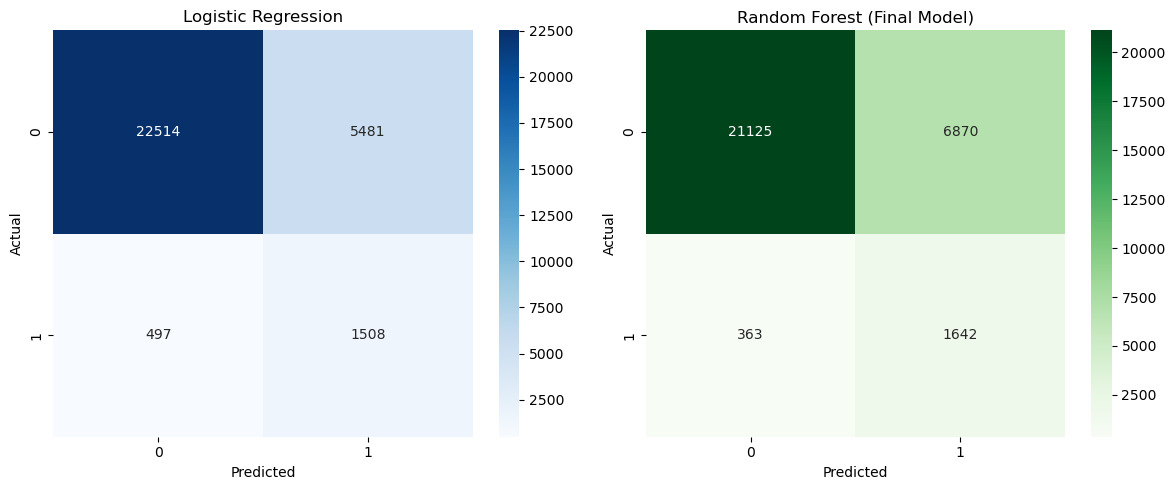

In [30]:
# Cell: Confusion matrix heatmap comparison — visual proof of the trade-off
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr_final)
cm_rf = confusion_matrix(y_test, y_pred_rf_final)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest (Final Model)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

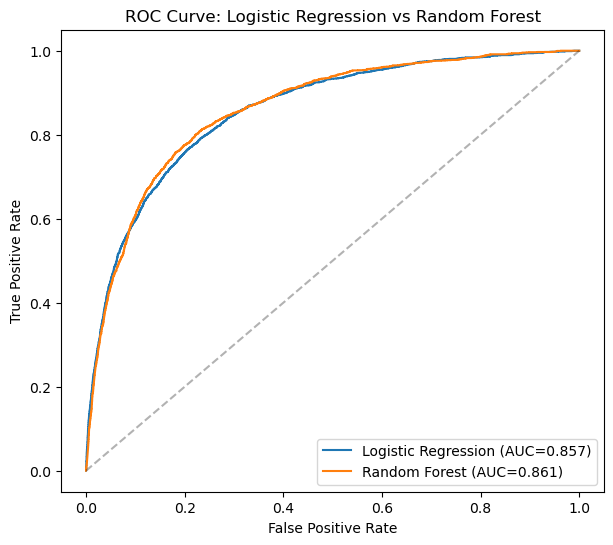

In [31]:
# Cell: ROC curve comparison
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_final)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_final)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr_final):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf_final):.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression vs Random Forest')
plt.legend()
plt.show()

In [32]:
# Cell: Save the final model
import pickle
with open('credit_risk_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("Saved final Random Forest model")

Saved final Random Forest model
